In [1]:
"""
FERTILITY INDEX CREATION - JUPYTER NOTEBOOK VERSION
===================================================

Copy this entire code into a Jupyter notebook cell and run it.

This creates a Composite Fertility Index using research-based weights.

COMPONENTS & WEIGHTS:
- Nitrogen:      40%
- pH:            25%
- NDVI:          15%
- SoilMoisture:  10%
- Clay:          10%

OUTPUTS:
- Adds 'FertilityIndex' and 'FertilityClass' columns to dataframe
- Creates visualization dashboard
- Prints summary statistics
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FERTILITY INDEX CREATION - NOTEBOOK VERSION")
print("="*80)

FERTILITY INDEX CREATION - NOTEBOOK VERSION


In [2]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================

# Research-based weights
WEIGHTS = {
    'Nitrogen': 0.40,
    'pH': 0.25,
    'NDVI': 0.15,
    'SoilMoisture': 0.10,
    'Clay': 0.10
}

# Fertility thresholds
THRESHOLDS = {'High': 0.7, 'Medium': 0.4}

# pH settings
PH_OPTIMAL = 6.5
PH_TOLERANCE = 1.0

print(f"\nWeights: {WEIGHTS}")
print(f"Thresholds: High ≥ {THRESHOLDS['High']}, Medium ≥ {THRESHOLDS['Medium']}")


Weights: {'Nitrogen': 0.4, 'pH': 0.25, 'NDVI': 0.15, 'SoilMoisture': 0.1, 'Clay': 0.1}
Thresholds: High ≥ 0.7, Medium ≥ 0.4


In [3]:
# ==============================================================================
# LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

# Try different paths
try:
    df = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
    print(f"✓ Loaded from csv/ folder: {df.shape}")
except:
    df = pd.read_csv('Bangalore_Monthly_Final_Corrected.csv')
    print(f"✓ Loaded from current directory: {df.shape}")

# Verify columns
required_cols = ['Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay']
print(f"✓ Required columns present: {required_cols}")


1. LOADING DATA
------------------------------------------------------------
✓ Loaded from csv/ folder: (23042, 26)
✓ Required columns present: ['Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay']


In [4]:
# ==============================================================================
# NORMALIZATION
# ==============================================================================
print("\n2. NORMALIZING COMPONENTS")
print("-" * 60)

def normalize_minmax(values):
    """Min-max scaling to [0, 1]"""
    scaler = MinMaxScaler()
    return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

def normalize_ph_optimal(ph_values, optimal=PH_OPTIMAL, tolerance=PH_TOLERANCE):
    """pH normalization based on distance from optimal"""
    deviation = np.abs(ph_values - optimal)
    scores = 1 - (deviation / tolerance)
    return np.clip(scores, 0, 1)

# Apply normalization
df['N_score'] = normalize_minmax(df['Nitrogen'])
df['pH_score'] = normalize_ph_optimal(df['pH'])
df['NDVI_score'] = normalize_minmax(df['NDVI'])
df['Moisture_score'] = normalize_minmax(df['SoilMoisture'])
df['Clay_score'] = normalize_minmax(df['Clay'])

print("✓ All components normalized to [0, 1]")


2. NORMALIZING COMPONENTS
------------------------------------------------------------
✓ All components normalized to [0, 1]


In [5]:
# ==============================================================================
# CALCULATE FERTILITY INDEX
# ==============================================================================
print("\n3. CALCULATING FERTILITY INDEX")
print("-" * 60)

df['FertilityIndex'] = (
    WEIGHTS['Nitrogen'] * df['N_score'] +
    WEIGHTS['pH'] * df['pH_score'] +
    WEIGHTS['NDVI'] * df['NDVI_score'] +
    WEIGHTS['SoilMoisture'] * df['Moisture_score'] +
    WEIGHTS['Clay'] * df['Clay_score']
)

print(f"✓ Fertility Index created")
print(f"  Range: [{df['FertilityIndex'].min():.3f}, {df['FertilityIndex'].max():.3f}]")
print(f"  Mean:  {df['FertilityIndex'].mean():.3f} ± {df['FertilityIndex'].std():.3f}")
print(f"  Median: {df['FertilityIndex'].median():.3f}")


3. CALCULATING FERTILITY INDEX
------------------------------------------------------------
✓ Fertility Index created
  Range: [0.266, 0.842]
  Mean:  0.418 ± 0.058
  Median: 0.411


In [6]:
# ==============================================================================
# CLASSIFY
# ==============================================================================
print("\n4. CLASSIFYING FERTILITY LEVELS")
print("-" * 60)

def classify_fertility(fi_score):
    if fi_score >= THRESHOLDS['High']:
        return 'High'
    elif fi_score >= THRESHOLDS['Medium']:
        return 'Medium'
    else:
        return 'Low'

df['FertilityClass'] = df['FertilityIndex'].apply(classify_fertility)

class_counts = df['FertilityClass'].value_counts()
print(f"\nClass distribution:")
for cls in ['High', 'Medium', 'Low']:
    if cls in class_counts.index:
        count = class_counts[cls]
        pct = count / len(df) * 100
        print(f"  {cls:8s}: {count:6d} ({pct:5.2f}%)")


4. CLASSIFYING FERTILITY LEVELS
------------------------------------------------------------

Class distribution:
  High    :    114 ( 0.49%)
  Medium  :  13602 (59.03%)
  Low     :   9326 (40.47%)


In [7]:
# ==============================================================================
# VALIDATION
# ==============================================================================
print("\n5. VALIDATION - CORRELATIONS")
print("-" * 60)

components = ['Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay']
print("\nCorrelation with FertilityIndex:")
for comp in components:
    corr = df[comp].corr(df['FertilityIndex'])
    print(f"  {comp:15s}: {corr:+.3f}")


5. VALIDATION - CORRELATIONS
------------------------------------------------------------

Correlation with FertilityIndex:
  Nitrogen       : +0.777
  pH             : -0.015
  NDVI           : +0.311
  SoilMoisture   : +0.326
  Clay           : +0.434



6. CREATING VISUALIZATIONS
------------------------------------------------------------
✓ Saved: Fertility_Index_Analysis_Notebook.png


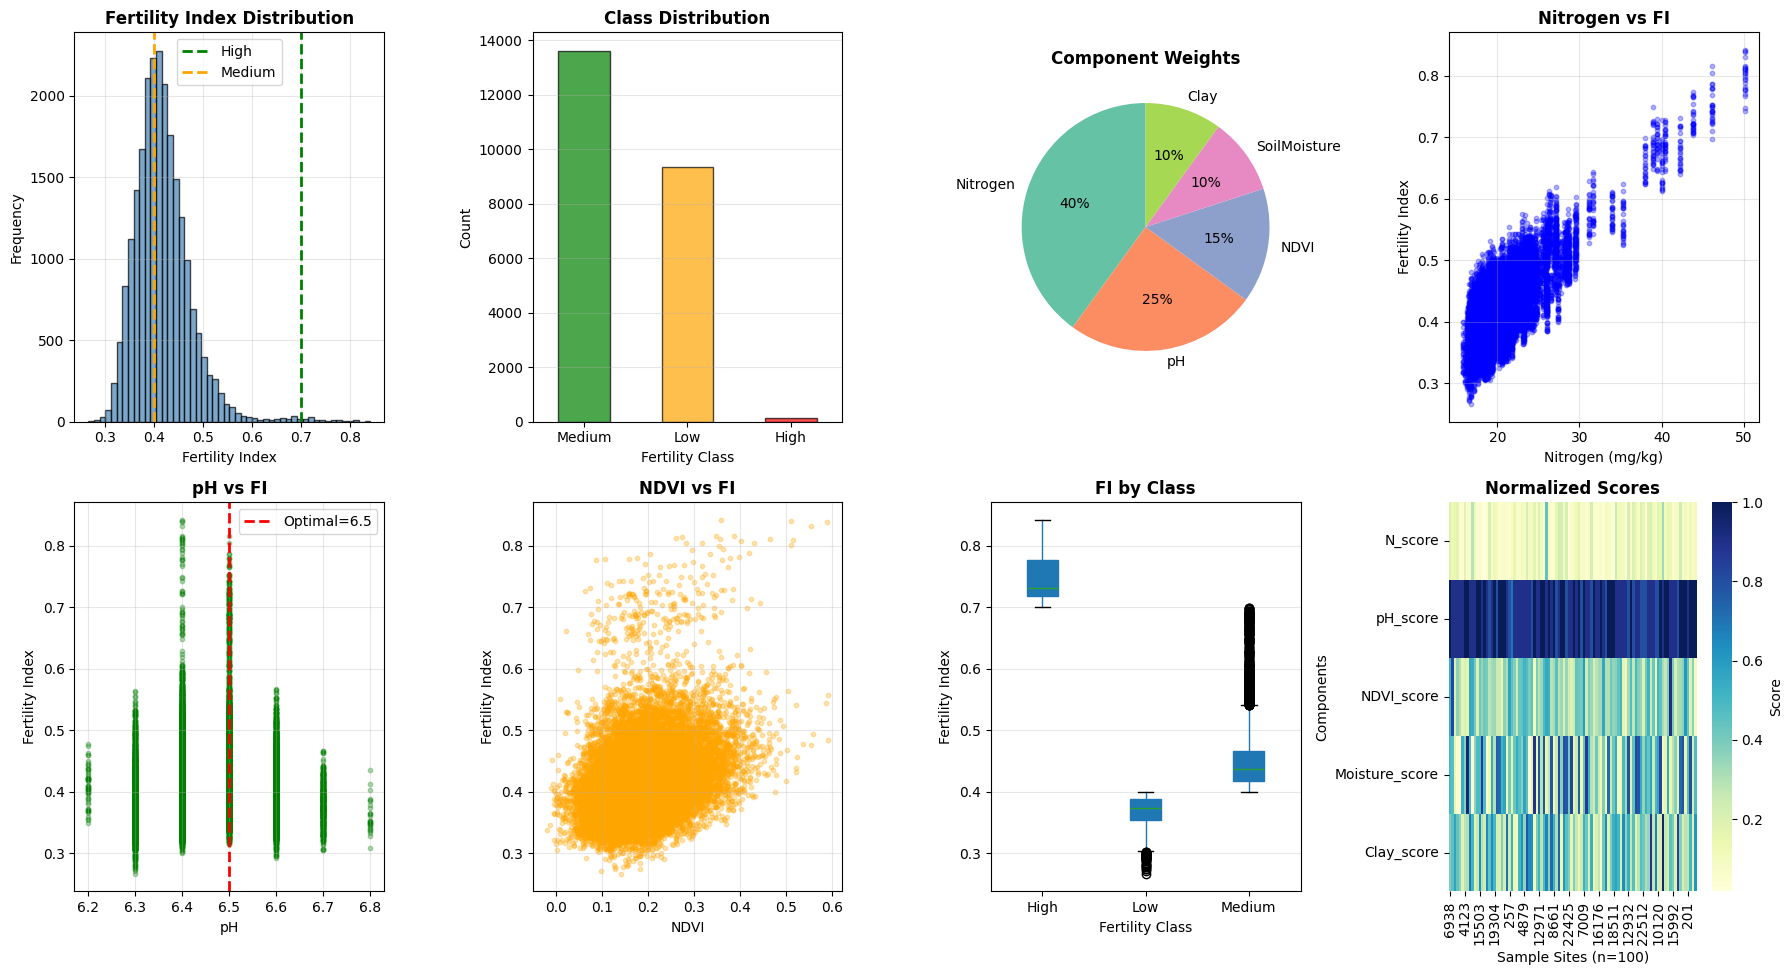

In [8]:
# ==============================================================================
# VISUALIZATIONS
# ==============================================================================
print("\n6. CREATING VISUALIZATIONS")
print("-" * 60)

fig = plt.figure(figsize=(18, 10))

# 1. FI Distribution
ax1 = plt.subplot(2, 4, 1)
plt.hist(df['FertilityIndex'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(THRESHOLDS['High'], color='green', linestyle='--', linewidth=2, label='High')
plt.axvline(THRESHOLDS['Medium'], color='orange', linestyle='--', linewidth=2, label='Medium')
plt.xlabel('Fertility Index')
plt.ylabel('Frequency')
plt.title('Fertility Index Distribution', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 2. Class Counts
ax2 = plt.subplot(2, 4, 2)
class_counts.plot(kind='bar', color=['green', 'orange', 'red'], edgecolor='black', alpha=0.7)
plt.xlabel('Fertility Class')
plt.ylabel('Count')
plt.title('Class Distribution', fontweight='bold')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')

# 3. Component Weights
ax3 = plt.subplot(2, 4, 3)
plt.pie(WEIGHTS.values(), labels=WEIGHTS.keys(), autopct='%1.0f%%', 
        startangle=90, colors=sns.color_palette('Set2'))
plt.title('Component Weights', fontweight='bold')

# 4. Nitrogen vs FI
ax4 = plt.subplot(2, 4, 4)
plt.scatter(df['Nitrogen'], df['FertilityIndex'], alpha=0.3, s=10, c='blue')
plt.xlabel('Nitrogen (mg/kg)')
plt.ylabel('Fertility Index')
plt.title('Nitrogen vs FI', fontweight='bold')
plt.grid(alpha=0.3)

# 5. pH vs FI
ax5 = plt.subplot(2, 4, 5)
plt.scatter(df['pH'], df['FertilityIndex'], alpha=0.3, s=10, c='green')
plt.axvline(PH_OPTIMAL, color='red', linestyle='--', linewidth=2, label=f'Optimal={PH_OPTIMAL}')
plt.xlabel('pH')
plt.ylabel('Fertility Index')
plt.title('pH vs FI', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 6. NDVI vs FI
ax6 = plt.subplot(2, 4, 6)
plt.scatter(df['NDVI'], df['FertilityIndex'], alpha=0.3, s=10, c='orange')
plt.xlabel('NDVI')
plt.ylabel('Fertility Index')
plt.title('NDVI vs FI', fontweight='bold')
plt.grid(alpha=0.3)

# 7. FI by Class
ax7 = plt.subplot(2, 4, 7)
df.boxplot(column='FertilityIndex', by='FertilityClass', ax=ax7, patch_artist=True, grid=False)
plt.suptitle('')
plt.xlabel('Fertility Class')
plt.ylabel('Fertility Index')
plt.title('FI by Class', fontweight='bold')
plt.grid(alpha=0.3, axis='y')

# 8. Component Scores Heatmap
ax8 = plt.subplot(2, 4, 8)
sample_size = min(100, len(df))
sample_df = df.sample(sample_size)[['N_score', 'pH_score', 'NDVI_score', 
                                      'Moisture_score', 'Clay_score']].T
sns.heatmap(sample_df, cmap='YlGnBu', cbar_kws={'label': 'Score'}, ax=ax8)
plt.ylabel('Components')
plt.xlabel(f'Sample Sites (n={sample_size})')
plt.title('Normalized Scores', fontweight='bold')

plt.tight_layout()
plt.savefig('Fertility_Index_Analysis_Notebook.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Fertility_Index_Analysis_Notebook.png")
plt.show()

In [9]:
# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ FERTILITY INDEX CREATION COMPLETE")
print("="*80)

print(f"\n📊 SUMMARY:")
print(f"  • Samples processed: {len(df):,}")
print(f"  • FI range: [{df['FertilityIndex'].min():.3f}, {df['FertilityIndex'].max():.3f}]")
print(f"  • Mean FI: {df['FertilityIndex'].mean():.3f} ± {df['FertilityIndex'].std():.3f}")
print(f"\n  Class distribution:")
for cls in ['High', 'Medium', 'Low']:
    if cls in class_counts.index:
        count = class_counts[cls]
        pct = count / len(df) * 100
        print(f"    {cls:8s}: {count:6,} ({pct:5.2f}%)")

print("\n✓ New columns added to dataframe:")
print("  - FertilityIndex (continuous, 0-1)")
print("  - FertilityClass (categorical: High/Medium/Low)")
print("  - N_score, pH_score, NDVI_score, Moisture_score, Clay_score")

print("\n" + "="*80)

# Display sample
print("\nSample of results:")
display_cols = ['Nitrogen', 'pH', 'NDVI', 'SoilMoisture', 'Clay', 
                'FertilityIndex', 'FertilityClass']
print(df[display_cols].head(10))


✅ FERTILITY INDEX CREATION COMPLETE

📊 SUMMARY:
  • Samples processed: 23,042
  • FI range: [0.266, 0.842]
  • Mean FI: 0.418 ± 0.058

  Class distribution:
    High    :    114 ( 0.49%)
    Medium  : 13,602 (59.03%)
    Low     :  9,326 (40.47%)

✓ New columns added to dataframe:
  - FertilityIndex (continuous, 0-1)
  - FertilityClass (categorical: High/Medium/Low)
  - N_score, pH_score, NDVI_score, Moisture_score, Clay_score


Sample of results:
   Nitrogen   pH      NDVI  SoilMoisture  Clay  FertilityIndex FertilityClass
0      19.4  6.4  0.288160      0.199702  20.8        0.402771         Medium
1      17.5  6.4  0.409249      0.195375  22.4        0.419541         Medium
2      18.8  6.4  0.281929      0.199702  23.2        0.410138         Medium
3      16.9  6.4  0.322476      0.200571  23.8        0.402188         Medium
4      19.6  6.4  0.282675      0.205728  22.8        0.418945         Medium
5      17.5  6.4  0.291505      0.205728  22.3        0.393311            Low
6